In [3]:
# Cell 1 — Setup & Load UCI Heart Disease (processed.cleveland.data)

import os
import numpy as np
import pandas as pd

# --- Paths (relative to the notebook) ---
DATA_PATH = os.path.join("..", "data", "raw", "uci_heart_disease", "processed.cleveland.data")
NAMES_PATH = os.path.join("..", "data", "raw", "uci_heart_disease", "heart-disease.names")

print("Looking for dataset at:", os.path.abspath(DATA_PATH))
print("Looking for dictionary at:", os.path.abspath(NAMES_PATH))

# --- Column names for processed.cleveland.data (standard UCI order) ---
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "num"
]

# --- Load data (treat '?' as missing) ---
df = pd.read_csv(DATA_PATH, header=None, names=columns, na_values="?")

print("\nShape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())

df.head(10)


Looking for dataset at: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\Assignment3\data\raw\uci_heart_disease\processed.cleveland.data
Looking for dictionary at: c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\Assignment3\data\raw\uci_heart_disease\heart-disease.names

Shape: (303, 14)

Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [4]:
# Cell 2 — Data preprocessing and target creation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Create binary target ---
# num = 0 -> no disease
# num >= 1 -> disease present
df["target"] = (df["num"] >= 1).astype(int)

# --- Drop original multi-class target ---
df = df.drop(columns=["num"])

# --- Handle missing values ---
# For Cleveland dataset, missing values are typically in 'ca' and 'thal'
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# --- Separate features and target ---
X = df.drop(columns=["target"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts())

# --- Train-test split (80/20 as per assignment) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Scale numeric features ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining samples:", X_train_scaled.shape[0])
print("Test samples:", X_test_scaled.shape[0])


Feature matrix shape: (303, 13)
Target distribution:
 target
0    164
1    139
Name: count, dtype: int64

Training samples: 242
Test samples: 61


In [5]:
# Cell 3 — Bayesian Logistic Regression (PyMC)

import pymc as pm
import arviz as az

# Convert to numpy arrays
Xtr = np.asarray(X_train_scaled, dtype=float)
Xte = np.asarray(X_test_scaled, dtype=float)
ytr = np.asarray(y_train.values, dtype=int)
yte = np.asarray(y_test.values, dtype=int)

n_features = Xtr.shape[1]

# Use training prevalence to set a sensible intercept prior (pre-test probability idea)
prev = ytr.mean()
logit_prev = np.log(prev / (1 - prev))
print("Training prevalence:", prev, " | logit(prevalence):", logit_prev)

with pm.Model() as bayes_logreg:
    # Priors (weakly informative)
    intercept = pm.Normal("intercept", mu=logit_prev, sigma=1.5)
    coefs = pm.Normal("coefs", mu=0.0, sigma=1.0, shape=n_features)

    # Linear predictor and logistic link
    logits = intercept + pm.math.dot(Xtr, coefs)
    p = pm.Deterministic("p", pm.math.sigmoid(logits))

    # Likelihood
    y_obs = pm.Bernoulli("y_obs", p=p, observed=ytr)

    # Sample posterior
    idata = pm.sample(
        draws=1200,
        tune=1200,
        chains=2,
        target_accept=0.9,
        random_seed=42
    )

az.summary(idata, var_names=["intercept", "coefs"]).head(10)


Training prevalence: 0.45867768595041325  | logit(prevalence): -0.16566712188881733


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, coefs]


c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\Assignment3\.venv\Lib\site-packages\rich\live.py:256: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_200 tune and 1_200 draw iterations (2_400 + 2_400 draws total) took 332 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
intercept,-0.080,0.209,-0.489,0.298,0.004,0.004,3143.0,1867.0,1.0
coefs[0],-0.119,0.240,-0.570,0.330,0.005,0.004,2692.0,1977.0,1.0
coefs[1],0.710,0.239,0.293,1.188,0.005,0.005,2508.0,1883.0,1.0
coefs[2],0.599,0.207,0.185,0.961,0.004,0.004,3118.0,2043.0,1.0
coefs[3],0.341,0.207,-0.026,0.727,0.004,0.004,2886.0,1938.0,1.0
coefs[4],0.229,0.201,-0.129,0.622,0.004,0.004,2843.0,2139.0,1.0
coefs[5],-0.240,0.200,-0.605,0.141,0.003,0.004,3284.0,1828.0,1.0
coefs[6],0.246,0.211,-0.173,0.617,0.003,0.004,3780.0,1723.0,1.0
coefs[7],-0.378,0.253,-0.882,0.068,0.005,0.004,2600.0,1932.0,1.0
coefs[8],0.409,0.211,-0.015,0.783,0.004,0.004,3492.0,1803.0,1.0


Accuracy: 0.8688524590163934
Log-likelihood: -0.3202002710481608
ROC AUC: 0.9512987012987013


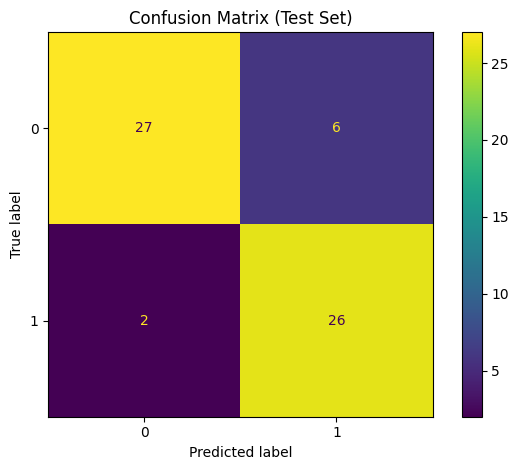

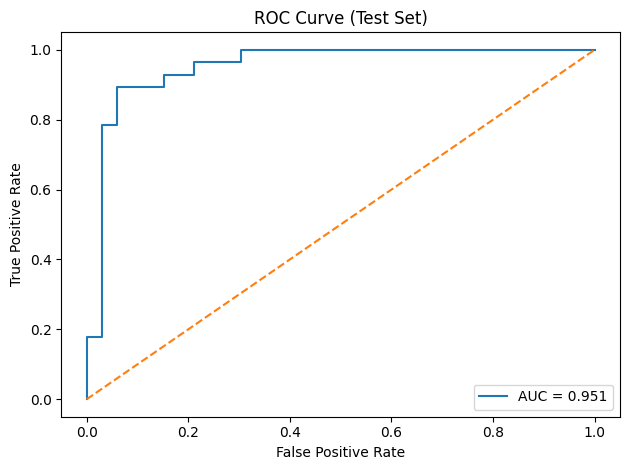

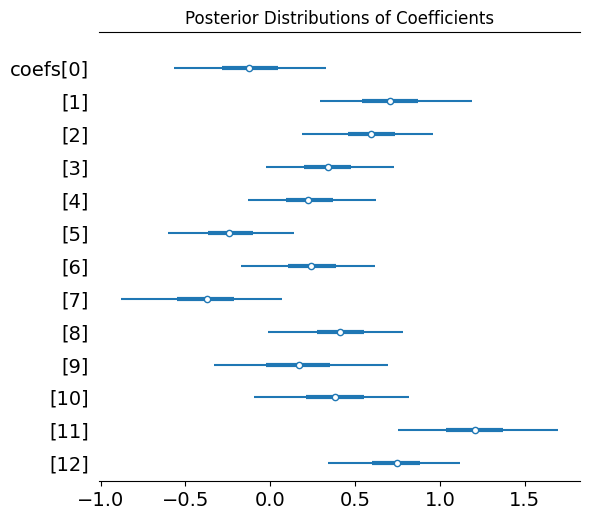


Saved figures:
 - c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\Assignment3\reports\figures\confusion_matrix.png
 - c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\Assignment3\reports\figures\roc_curve.png
 - c:\Users\dubey\Documents\UC_GitLab\Spring_2026_BI_Sem_1\Assignment3\reports\figures\posterior_forest.png


In [6]:
# Cell 4 — Predict on test set + metrics + plots saved for report

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Posterior samples
posterior = idata.posterior
intercept_s = posterior["intercept"].values.reshape(-1)          # (samples,)
coefs_s = posterior["coefs"].values.reshape(-1, n_features)      # (samples, features)

# Posterior predictive probabilities on test set
logits_samples = intercept_s[:, None] + coefs_s @ Xte.T          # (samples, n_test)
p_samples = 1 / (1 + np.exp(-logits_samples))
p_mean = p_samples.mean(axis=0)

# Classify
y_pred = (p_mean >= 0.5).astype(int)

# Metrics
acc = accuracy_score(yte, y_pred)
ll = -log_loss(yte, p_mean)     # log-likelihood proxy (negative log-loss)
auc = roc_auc_score(yte, p_mean)

print("Accuracy:", acc)
print("Log-likelihood:", ll)
print("ROC AUC:", auc)

# Ensure figures folder exists
fig_dir = os.path.join("..", "reports", "figures")
os.makedirs(fig_dir, exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(yte, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
cm_path = os.path.join(fig_dir, "confusion_matrix.png")
plt.savefig(cm_path, dpi=200)
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(yte, p_mean)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.tight_layout()
roc_path = os.path.join(fig_dir, "roc_curve.png")
plt.savefig(roc_path, dpi=200)
plt.show()

# Posterior coefficients plot
az.plot_forest(idata, var_names=["coefs"], combined=True)
plt.title("Posterior Distributions of Coefficients")
plt.tight_layout()
post_path = os.path.join(fig_dir, "posterior_forest.png")
plt.savefig(post_path, dpi=200)
plt.show()

print("\nSaved figures:")
print(" -", os.path.abspath(cm_path))
print(" -", os.path.abspath(roc_path))
print(" -", os.path.abspath(post_path))
